In [1]:
from typing import List, Dict, Optional
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from model_ranking.utils import (
    get_output_paths,
    load_h5,
)

/tmp/ipykernel_1944870/3001502080.py:61: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))


Proportion non NaN patches = 0.84


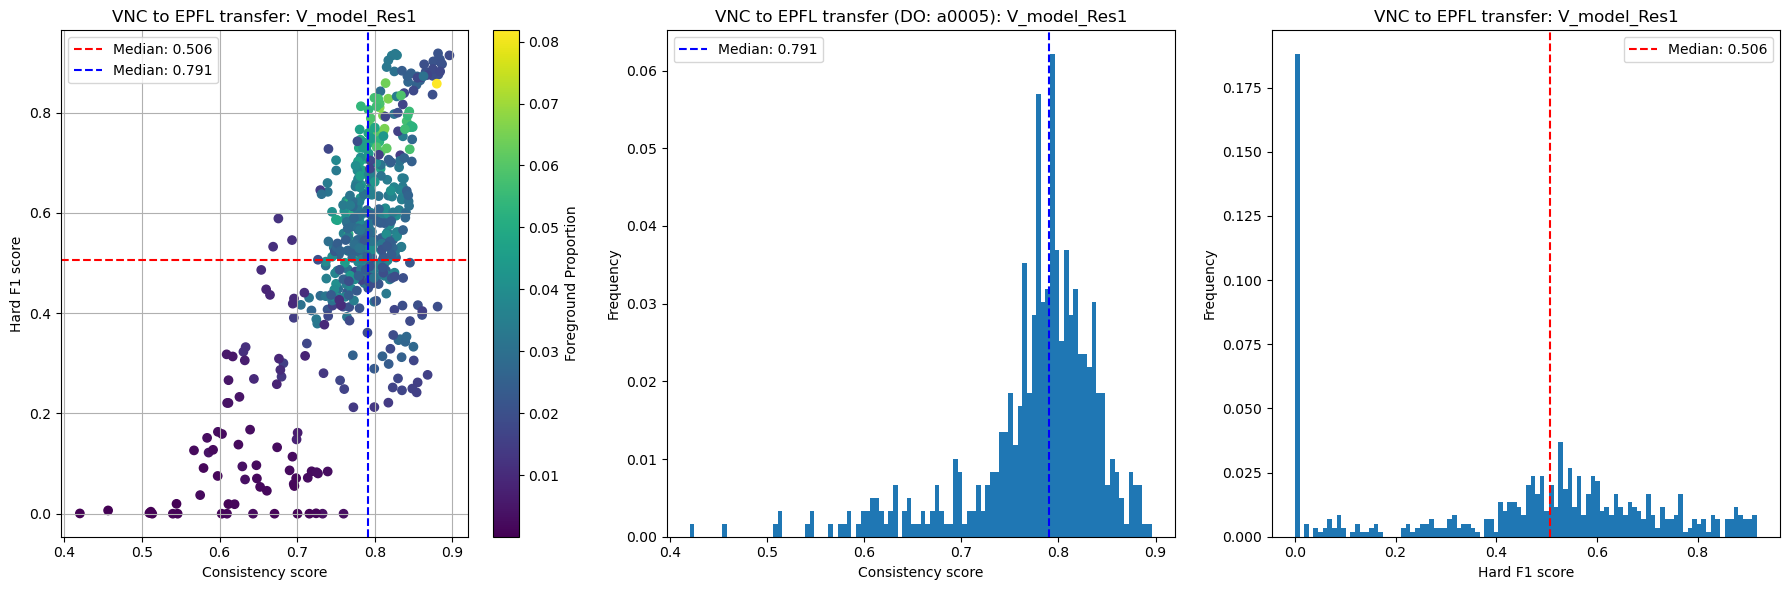

Proportion non NaN patches = 0.84


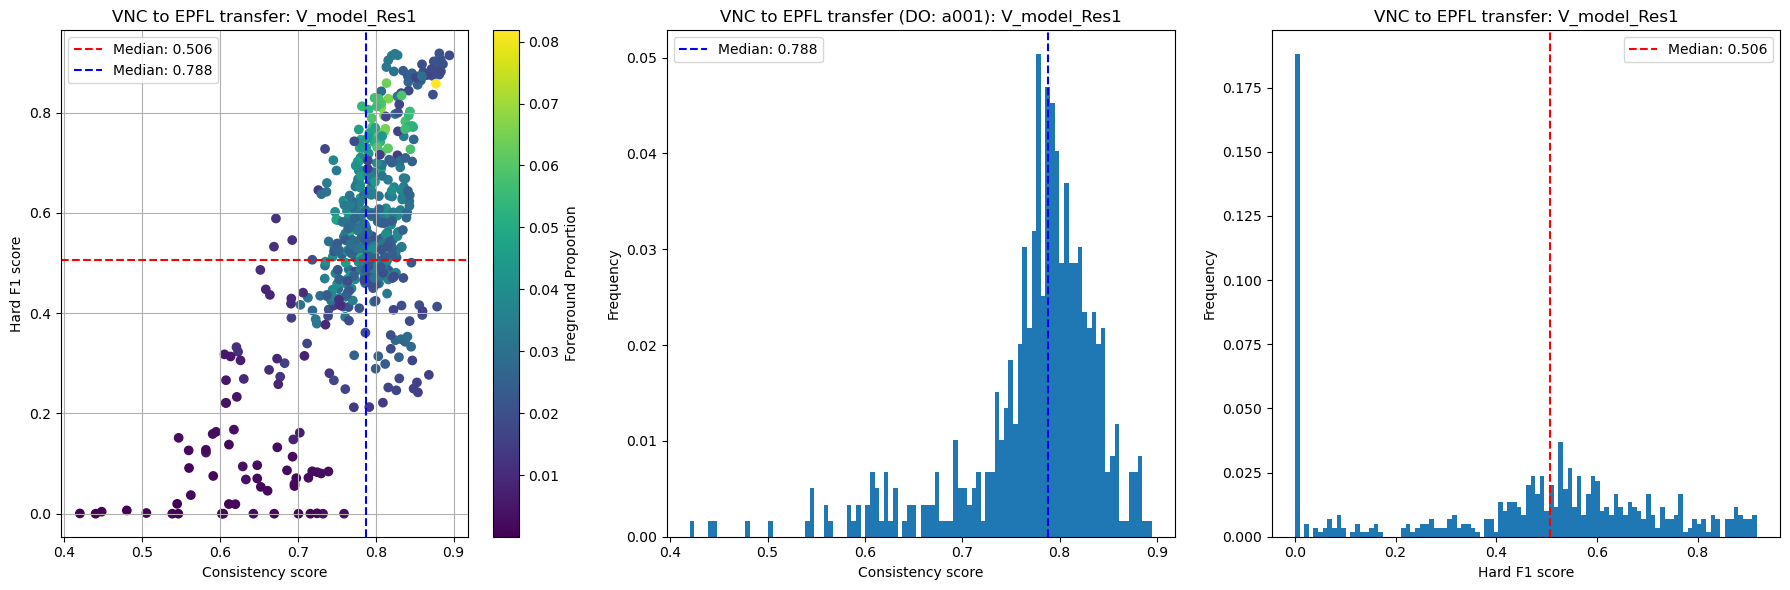

Proportion non NaN patches = 0.84


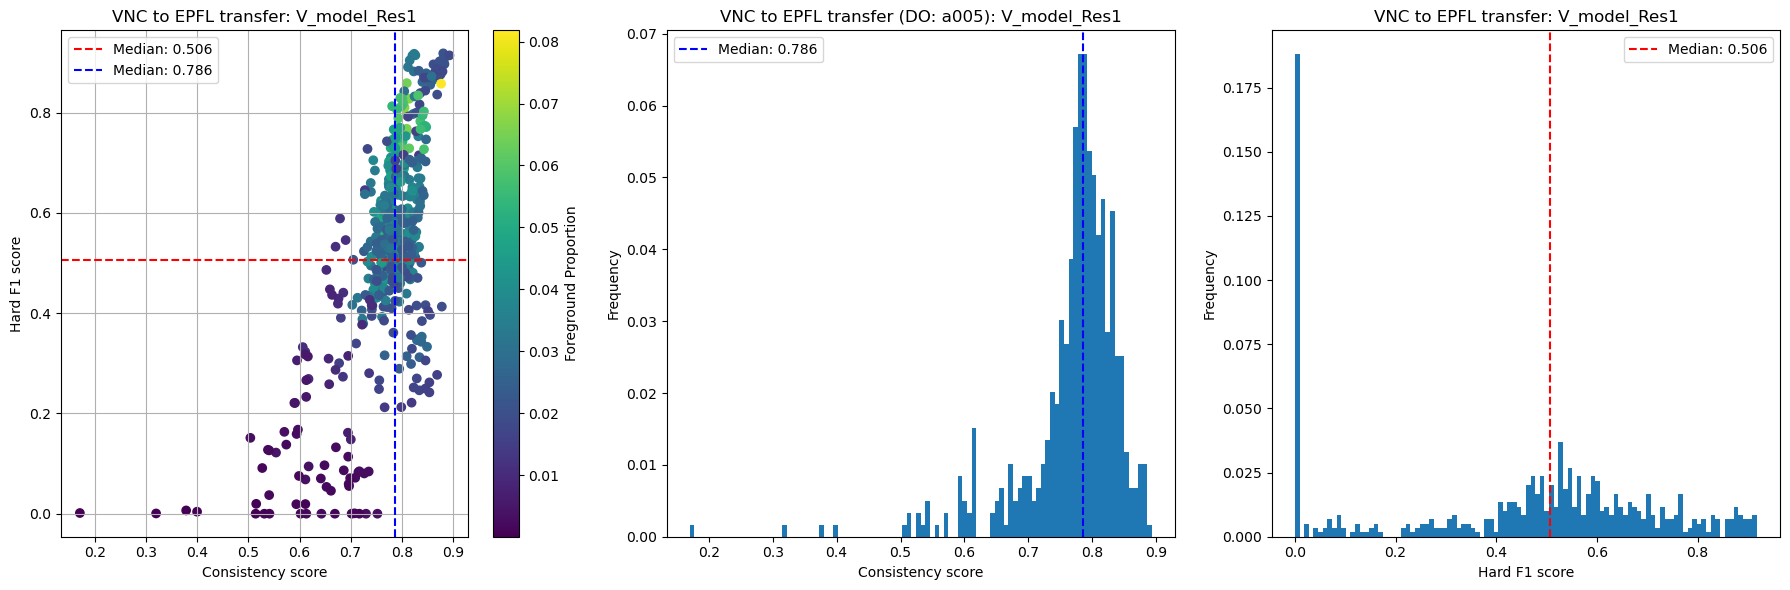

Proportion non NaN patches = 0.84


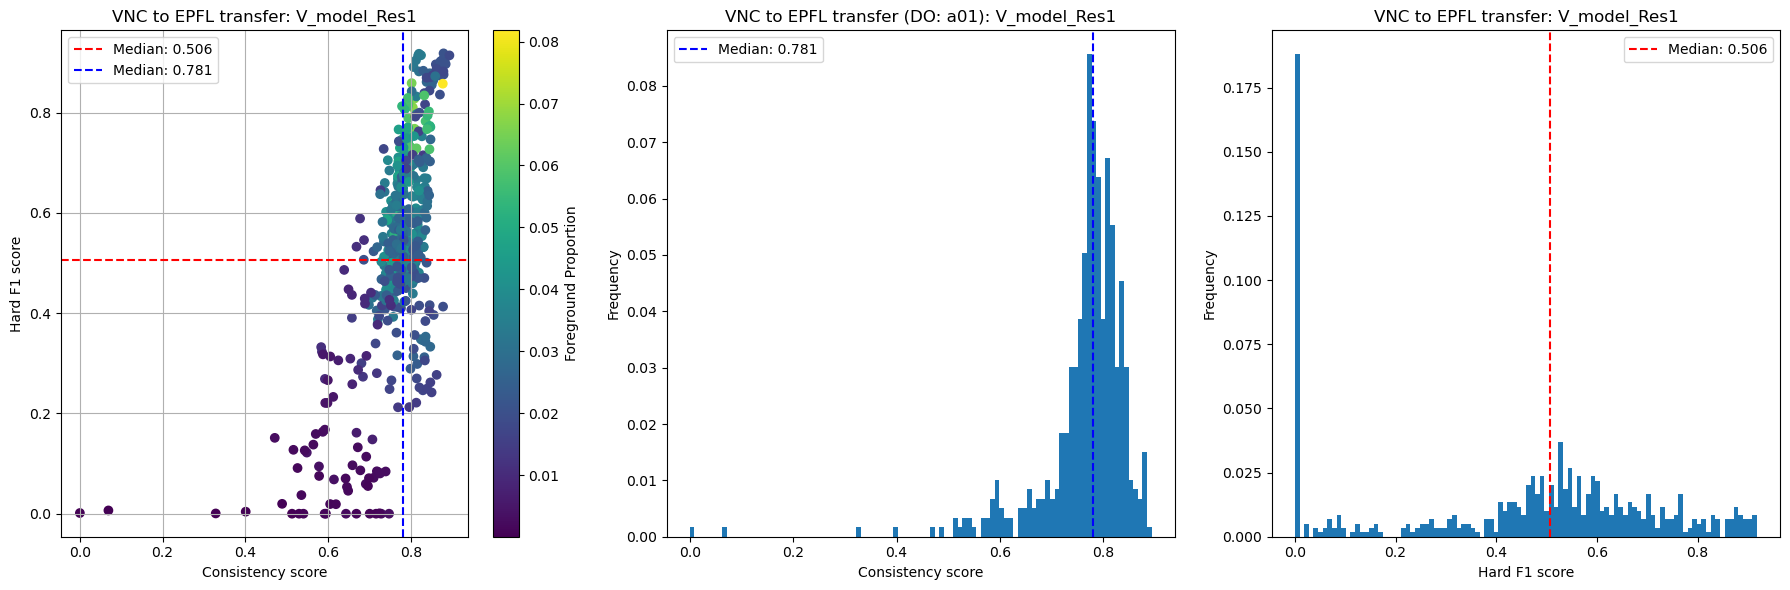

Proportion non NaN patches = 0.84


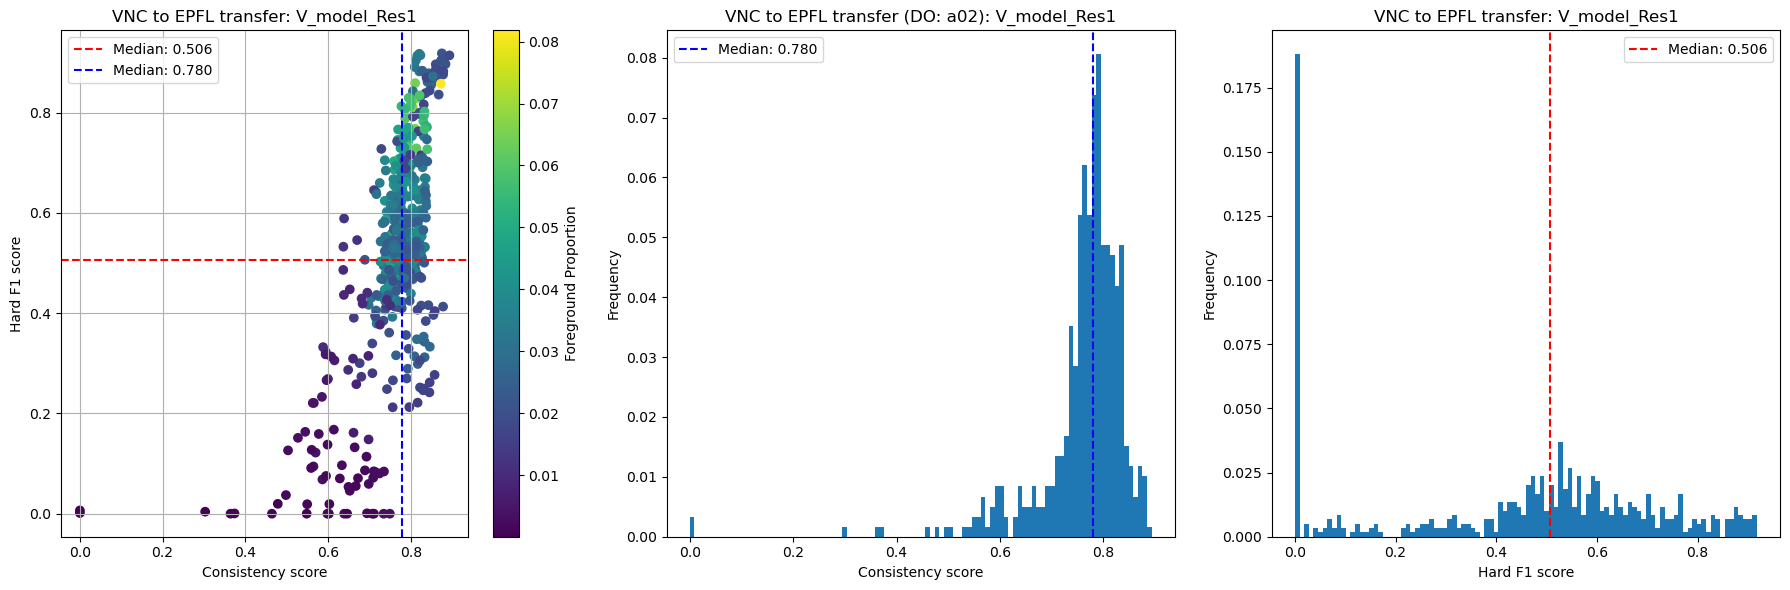

Proportion non NaN patches = 0.85


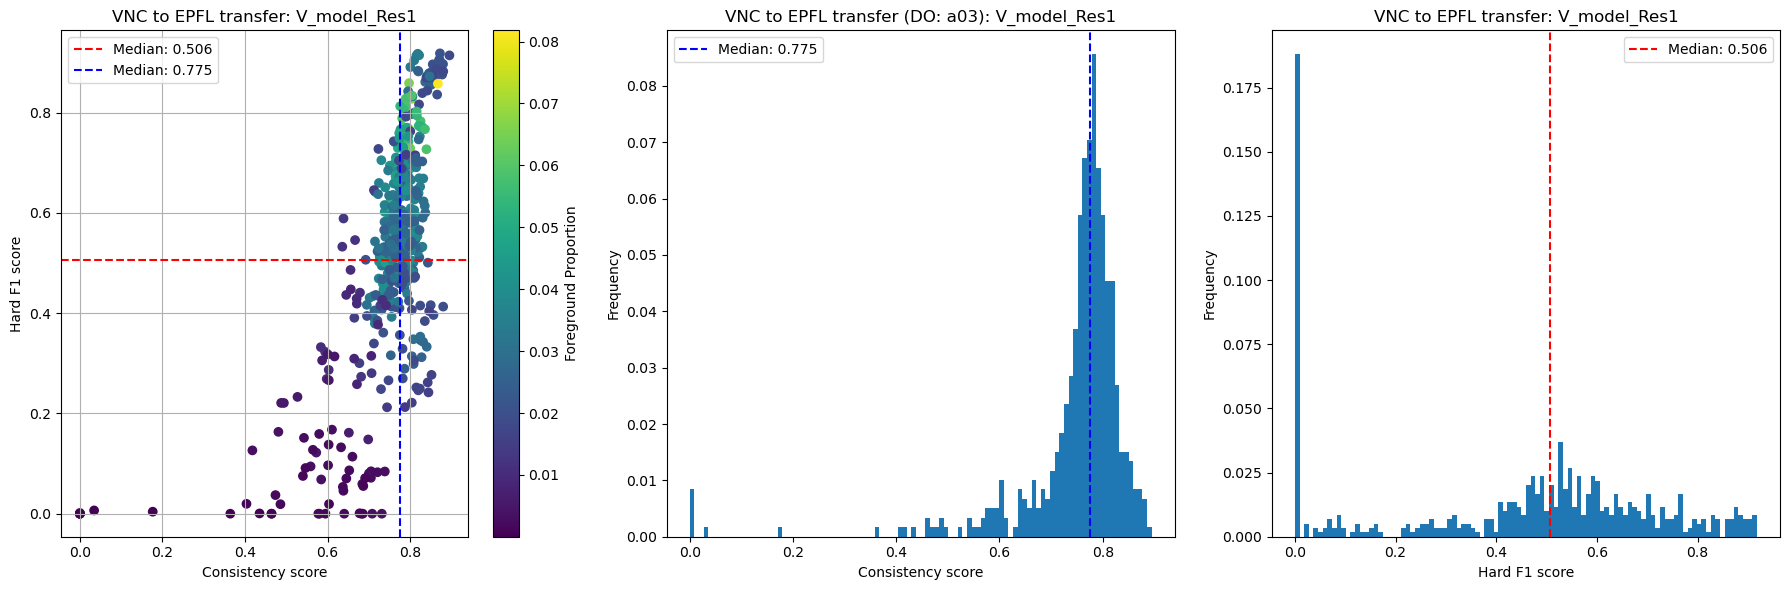

Proportion non NaN patches = 0.85


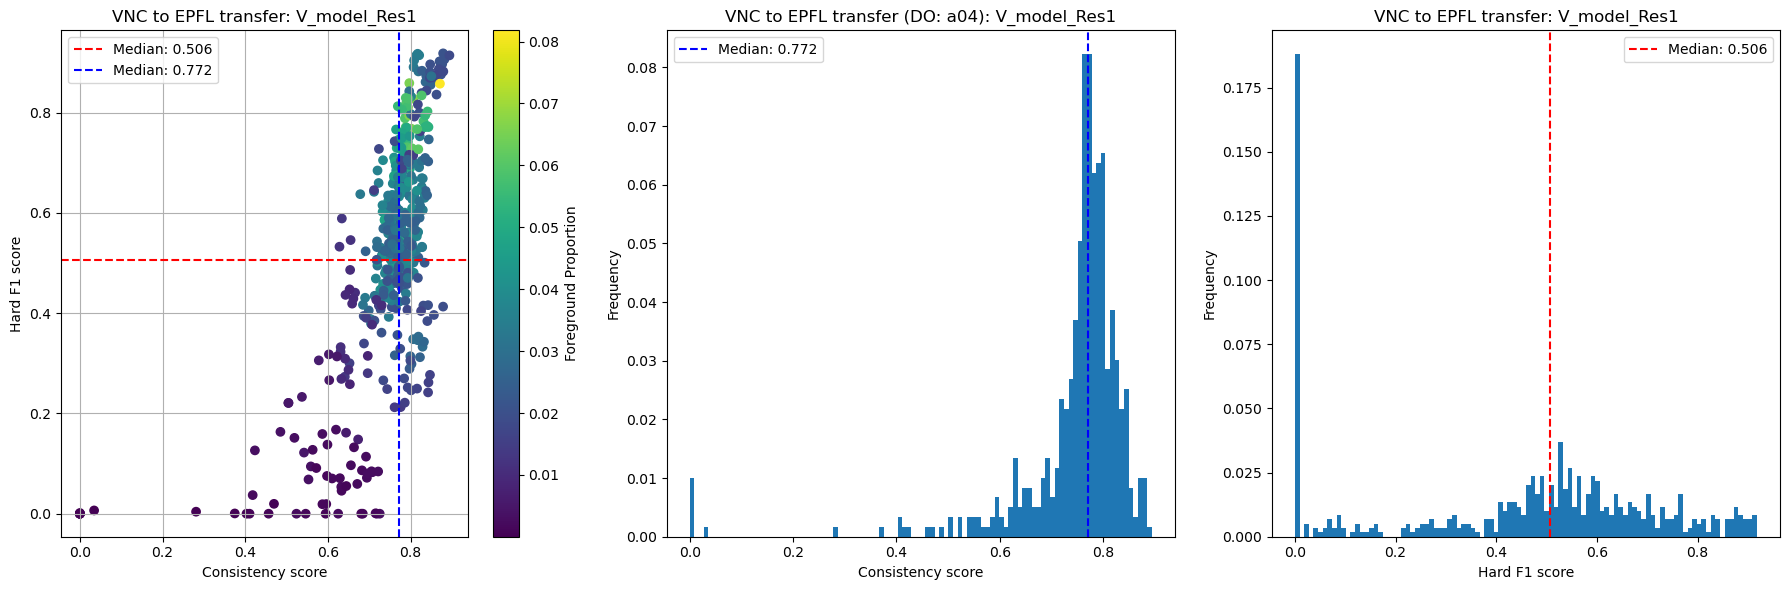

In [27]:
sources = {
    "VNC": "V_model_Res1",
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["EPFL", "Hmito", "Rmito"]
targets=["EPFL"]
result_folders = {
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_key = "EI_consis"
selected_alphas = ["a0005", "a001", "a005", "a01", "a02", "a03", "a04"]
#targets = ["VNC"]
# foreground_thresholds: Optional[Dict[str, float]] = {
#     "EPFL": 0.04,
#     "Hmito": 0.04,
#     "Rmito": 0.04,
#     "VNC": 0.02,
# }
foreground_thresholds: Optional[Dict[str, float]] = None

for source, model_name in sources.items():
    for target in targets:
        none_paths = get_output_paths(
            source, 
            target, 
            {"none": []}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folders[target], 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(none_paths) == 1, f"Expected one path for {source} to {target} transfer: {model_name}, found {len(paths)}"
        direct_pred_path: List[Path] = list(Path(none_paths[0]).glob("*.h5"))
        direct_pred_path = [p for p in direct_pred_path if "metric_summary" not in p.name]
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")[:,1]

        foreground_gt_patches = load_h5(direct_pred_path[0], "foreground_patches_th002")
        eval_score_direct = eval_score_direct[foreground_gt_patches]

        for perturbation_alpha in selected_alphas:

            DO_paths = get_output_paths(
                source, 
                target, 
                {"DO": [perturbation_alpha]}, 
                [None], 
                model_name, 
                "predictions", 
                result_folder = result_folders[target], 
                base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
            )
            
            DO_pred_path: List[Path] = list(Path(DO_paths[0]).glob("*.h5"))
            DO_pred_path = [p for p in DO_pred_path if "metric_summary" not in p.name]

            consis_score_direct = load_h5(DO_pred_path[0], consis_key)
            consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))
            pred_foreground_proportions = np.count_nonzero(~np.isnan(consis_score_direct), axis=(1,2))/consis_score_direct[0].size
            pred_foreground_proportions = pred_foreground_proportions[foreground_gt_patches]

            consis_score_PP = consis_score_PP[foreground_gt_patches]


            if foreground_thresholds is not None:
                sel_ids = np.where(pred_foreground_proportions > foreground_thresholds[source])[0]
                consis_score_PP = consis_score_PP[sel_ids]
                eval_score_direct = eval_score_direct[sel_ids]
                pred_foreground_proportions = pred_foreground_proportions[sel_ids]
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)
            else:
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)

            print(f"Proportion non NaN patches = {(len(consis_score_PP) - np.isnan(consis_score_PP).sum()) / len(consis_score_PP):.2f}")
            _, axs = plt.subplots(1, 3, figsize=(18, 6))
            sc = axs[0].scatter(consis_score_PP, eval_score_direct, c=pred_foreground_proportions, cmap='viridis')
            _ = axs[0].set_xlabel("Consistency score")
            _ = plt.colorbar(sc, ax=axs[0], label='Foreground Proportion')
            _ = axs[0].set_ylabel("Hard F1 score")
            _ = axs[0].grid()
            _ = axs[0].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[0].axhline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[0].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[0].legend()
            _ = axs[1].hist(consis_score_PP, bins=100, weights=np.ones_like(consis_score_PP) / len(consis_score_PP))
            _ = axs[1].set_title(f"{source} to {target} transfer (DO: {perturbation_alpha}): {model_name}")
            _ = axs[1].set_xlabel("Consistency score")
            _ = axs[1].set_ylabel("Frequency")
            _ = axs[1].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[1].legend()
            _ = axs[2].hist(eval_score_direct, bins=100, weights=np.ones_like(eval_score_direct) / len(eval_score_direct))
            _ = axs[2].axvline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[2].legend()
            _ = axs[2].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[2].set_xlabel("Hard F1 score")
            _ = axs[2].set_ylabel("Frequency")
            plt.tight_layout()
            plt.show()
        

# Predictions

### VtoE predictions

In [28]:
E_path = "/scratch/talks/data/EPFL/test.h5"
E_label = load_h5(E_path, "labels")

In [29]:
VtoE_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_EPFL_gap/feature_perturbation_consistency/FP_3/V_model_Res1/norm_Normalize/DO_a02/predictions/test_predictions.h5"
VtoE_predictions = load_h5(VtoE_path, "predictions")
VtoE_f1 = load_h5(VtoE_path, "hard_f1")[:,1]
VtoE_patch_ids = load_h5(VtoE_path, "patch_index")
VtoE_consis = load_h5(VtoE_path, "EI_consis")
E_gt_fore_ground_patches = load_h5(VtoE_path, "foreground_patches_th002")
VtoE_consis_PP = np.nanmean(VtoE_consis, axis=tuple(range(1, VtoE_consis.ndim)))

/tmp/ipykernel_1944870/1488499093.py:7: RuntimeWarning: Mean of empty slice
  VtoE_consis_PP = np.nanmean(VtoE_consis, axis=tuple(range(1, VtoE_consis.ndim)))


In [30]:
### Only investigate foreground patches
VtoE_consis_PP = VtoE_consis_PP[E_gt_fore_ground_patches]
VtoE_f1 = VtoE_f1[E_gt_fore_ground_patches]
VtoE_predictions = VtoE_predictions[E_gt_fore_ground_patches]

In [37]:
nan_ids = np.where(np.isnan(VtoE_consis_PP))[0]
print(len(nan_ids))

96


In [34]:
print(f"Number of patches with F1 score 0: {len(np.where(VtoE_f1 == 0)[0])}")

Number of patches with F1 score 0: 110


In [42]:
f1_ids = np.where((VtoE_f1 > 0) & (VtoE_f1 < 0.2))[0]
print(f"Number of patches: {len(f1_ids)}")

Number of patches: 35


In [36]:
all_nan_in_f1 = np.all(np.isin(nan_ids, f1_ids))
print(f"All nan_ids are within f1_ids: {all_nan_in_f1}")

All nan_ids are within f1_ids: True


In [48]:
for i in range(4):
    print(32* 2**(i))

32
64
128
256


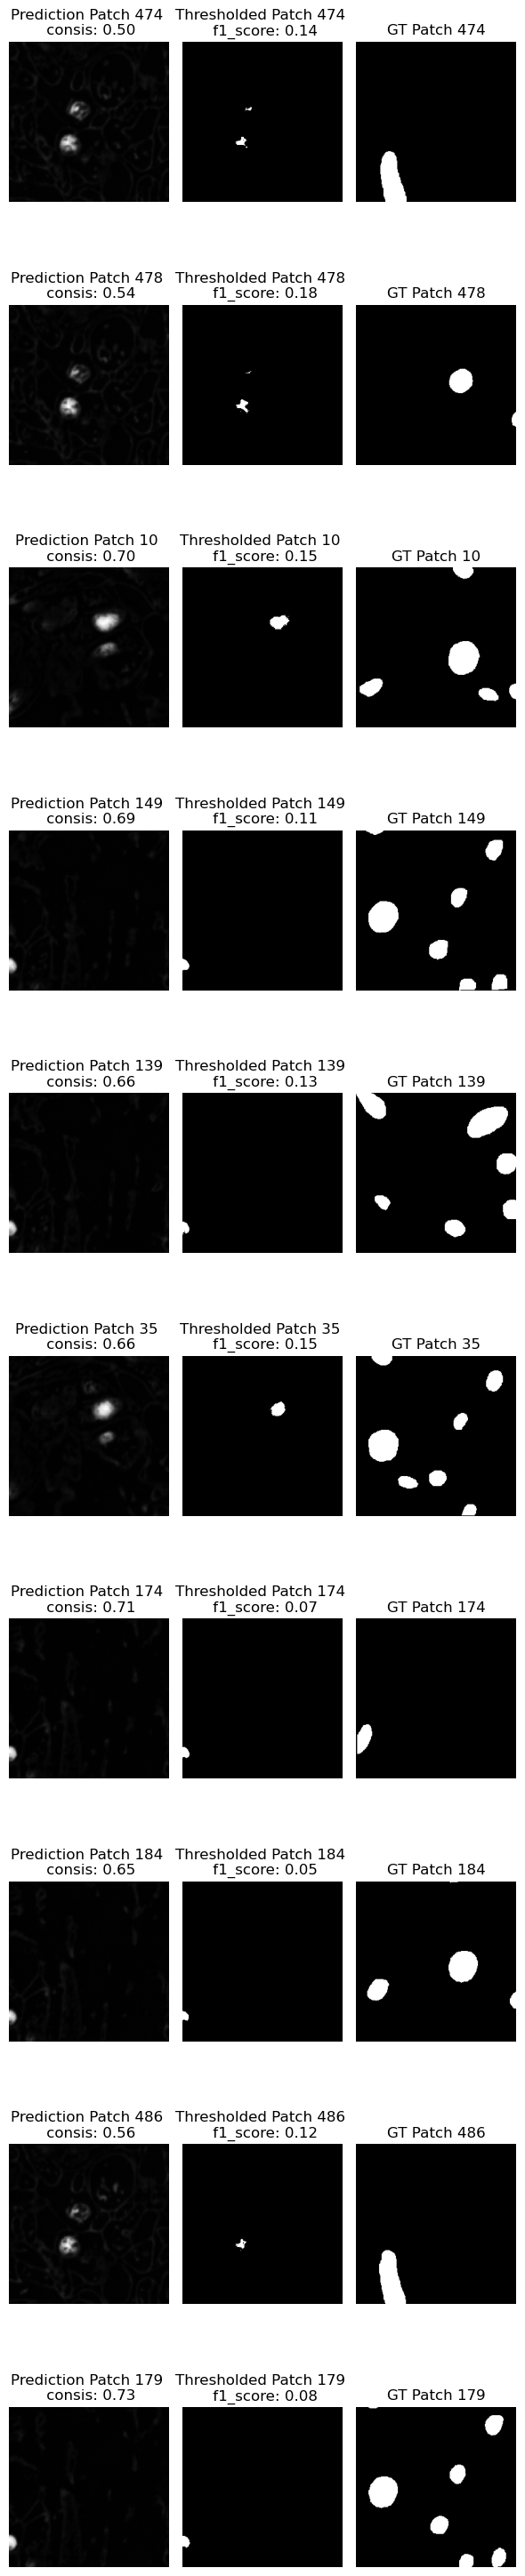

In [43]:
# Set random seed for reproducibility
data = E_label
patch_indexes = VtoE_patch_ids
preds = VtoE_predictions
ids = f1_ids
f1_scores = VtoE_f1
consis_scores = VtoE_consis_PP

np.random.seed(10)

# Randomly select 10 patch indices from ids_zero
sample_indices = np.random.choice(ids, size=10, replace=False)

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(6, 3 * len(sample_indices)))

for i, idx in enumerate(sample_indices):
    # Get patch coordinates
    z, y, x = patch_indexes[idx]
    # Extract prediction and ground truth patch
    pred_patch = preds[idx, 0, 0]
    gt_patch = data[z[0]:z[1], y[0]:y[1], x[0]:x[1]]

    # Plot prediction
    axes[i, 0].imshow(pred_patch.squeeze(), cmap='gray')
    axes[i, 0].set_title(f'Prediction Patch {idx} \n consis: {consis_scores[idx]:.2f}')
    axes[i, 0].axis('off')

    # Thresholded prediction
    axes[i, 1].imshow(pred_patch.squeeze() > 0.5, cmap='gray')
    axes[i, 1].set_title(f'Thresholded Patch {idx} \n f1_score: {f1_scores[idx]:.2f}')
    axes[i, 1].axis('off')

    # Plot ground truth
    axes[i, 2].imshow(gt_patch.squeeze(), cmap='gray')
    axes[i, 2].set_title(f'GT Patch {idx}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()